# Twitter Ego-Network — Exploratory Data Analysis

**Project:** Community Detection in Social Networks  
**Dataset:** SNAP ego-Twitter (https://snap.stanford.edu/data/ego-Twitter.html)  
**Authors:** Ahmet Doğaç Altın & Mükremin Berkay Can

## Goal of this notebook

Before running any community detection algorithm, we need to understand the dataset. This notebook answers:

1. What are the basic graph statistics? (nodes, edges, density, degree)
2. How is degree distributed? (power-law check)
3. Is the graph connected? How big is the largest connected component?
4. How does the directed → undirected conversion affect the graph?
5. What do the ego-networks look like individually? (for Plan B: ground-truth comparison)

**Pipeline plan:**  
**A (main):** Run Louvain & Leiden on `twitter_combined.txt`, compare modularity & runtime.  
**B (validation):** Run on individual ego-networks, compare detected communities vs. `circles` ground-truth using NMI/F1.

In [1]:
import sys
print(sys.executable)

/Users/dogacaltin/Desktop/cs 515 project/venv/bin/python


## 0. Setup

In [2]:
import os
import gzip
import time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import igraph as ig

# Where you extracted the SNAP files. Adjust if needed.
DATA_DIR = Path("./data")
COMBINED = DATA_DIR / "twitter_combined.txt"   # the big graph
EGO_DIR  = DATA_DIR / "twitter"                # folder with .edges, .circles, .feat, ...

print("Combined exists:", COMBINED.exists())
print("Ego dir exists:", EGO_DIR.exists())

Combined exists: True
Ego dir exists: True


## 1. Load the combined graph

`twitter_combined.txt` is a directed edge list: each line is `source target` meaning *source follows target*. We'll load it as a directed graph first, then convert to undirected for Louvain/Leiden (both algorithms work best on undirected graphs).

In [3]:
t0 = time.time()

g_dir = ig.Graph.Read_Ncol(str(COMBINED), directed=True, names=True)

print(f"Loaded in {time.time() - t0:.2f}s")
print(f"Directed graph:  |V| = {g_dir.vcount():,}   |E| = {g_dir.ecount():,}")
print(f"Density:        {g_dir.density():.6f}")
print(f"Is DAG?         {g_dir.is_dag()}")
print(f"Reciprocity:    {g_dir.reciprocity():.4f}  (fraction of mutual follows)")

Loaded in 1.32s
Directed graph:  |V| = 81,306   |E| = 2,420,766
Density:        0.000366
Is DAG?         False
Reciprocity:    0.5163  (fraction of mutual follows)


**Expected:** ~81K nodes, ~1.77M edges. Reciprocity tells us what fraction of follow relationships are mutual — important context for the directed→undirected decision.

In [4]:
# Convert to undirected. Two strategies:
#   (a) collapse: A→B and B→A become one edge A—B (default)
#   (b) mutual:  keep edge only if both A→B AND B→A exist
# Strategy (a) is standard for community detection — keeps more signal.

g = g_dir.as_undirected(mode="collapse")
g.simplify(multiple=True, loops=True)   # remove duplicate edges and self-loops

print(f"Undirected graph: |V| = {g.vcount():,}   |E| = {g.ecount():,}")
print(f"Density:         {g.density():.6f}")
print(f"Avg degree:      {2 * g.ecount() / g.vcount():.2f}")

Undirected graph: |V| = 81,306   |E| = 1,342,296
Density:         0.000406
Avg degree:      33.02


## 2. Connected components

Louvain/Leiden run on the whole graph, but modularity is most meaningful on a connected graph. If the graph has many small components plus one giant one, we usually report results on the **giant connected component (GCC)**.

In [5]:
components = g.connected_components(mode="weak")
comp_sizes = sorted(components.sizes(), reverse=True)

print(f"Number of components: {len(comp_sizes)}")
print(f"Largest 5 sizes:      {comp_sizes[:5]}")
print(f"GCC fraction:         {comp_sizes[0] / g.vcount():.4f}")

# Distribution of small components
small_sizes = [s for s in comp_sizes if s < 100]
print(f"\nComponents with <100 nodes: {len(small_sizes)}")
print(f"Component size histogram (small ones):")
print(pd.Series(small_sizes).value_counts().sort_index().head(10))

Number of components: 1
Largest 5 sizes:      [81306]
GCC fraction:         1.0000

Components with <100 nodes: 0
Component size histogram (small ones):
Series([], Name: count, dtype: int64)


In [6]:
# Extract the giant connected component for the main analysis
gcc = components.giant()
print(f"GCC: |V| = {gcc.vcount():,}   |E| = {gcc.ecount():,}")
print(f"GCC density: {gcc.density():.6f}")

GCC: |V| = 81,306   |E| = 1,342,296
GCC density: 0.000406


## 3. Degree distribution

Twitter follow networks famously follow a power-law degree distribution (a few mega-hubs, many low-degree nodes). We plot it on log-log axes to check.

In [7]:
degrees = np.array(gcc.degree())

print(f"Degree stats:")
print(f"  min:    {degrees.min()}")
print(f"  median: {np.median(degrees):.0f}")
print(f"  mean:   {degrees.mean():.2f}")
print(f"  max:    {degrees.max()}")
print(f"  p95:    {np.percentile(degrees, 95):.0f}")
print(f"  p99:    {np.percentile(degrees, 99):.0f}")

Degree stats:
  min:    1
  median: 15
  mean:   33.02
  max:    3383
  p95:    117
  p99:    264


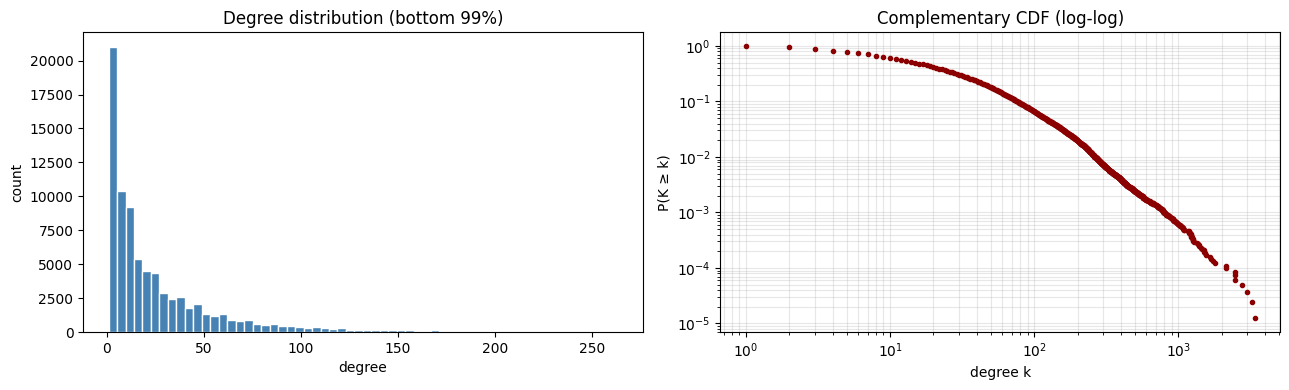

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Linear scale histogram (truncated for readability)
axes[0].hist(degrees[degrees < np.percentile(degrees, 99)], bins=60, color="steelblue", edgecolor="white")
axes[0].set_xlabel("degree")
axes[0].set_ylabel("count")
axes[0].set_title("Degree distribution (bottom 99%)")

# Log-log complementary CDF — best way to see power-law
deg_counts = Counter(degrees)
ks = np.array(sorted(deg_counts.keys()))
ps = np.array([deg_counts[k] for k in ks]) / len(degrees)
ccdf = np.cumsum(ps[::-1])[::-1]

axes[1].loglog(ks, ccdf, marker=".", linestyle="none", color="darkred")
axes[1].set_xlabel("degree k")
axes[1].set_ylabel("P(K ≥ k)")
axes[1].set_title("Complementary CDF (log-log)")
axes[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.savefig("degree_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

**Reading the plot:** A roughly straight line on the log-log CCDF indicates power-law-like behaviour, which means we have heavy-tailed degree distribution — a few super-connected nodes and a long tail of low-degree nodes. This is typical for social networks and is exactly the kind of structure where Louvain/Leiden tend to find non-trivial communities.

## 4. Quick clustering / triangle stats

High clustering coefficient is a hint that meaningful communities exist (friends-of-friends are also friends).

In [9]:
t0 = time.time()
global_cc = gcc.transitivity_undirected()
print(f"Global clustering coefficient: {global_cc:.4f}  (computed in {time.time()-t0:.1f}s)")

# Average local clustering — sample if too slow on full graph
t0 = time.time()
avg_local_cc = gcc.transitivity_avglocal_undirected(mode="zero")
print(f"Average local clustering:      {avg_local_cc:.4f}  (computed in {time.time()-t0:.1f}s)")

Global clustering coefficient: 0.1706  (computed in 0.1s)
Average local clustering:      0.5653  (computed in 0.1s)


## 5. Ego-networks — sample inspection (for Plan B)

Each ego has its own folder of files. The `.circles` file gives ground-truth groupings made by the ego user themselves. We'll inspect a few to understand the format and scale.

In [10]:
# List all ego IDs (one per .edges file)
ego_ids = sorted(set(p.stem for p in EGO_DIR.glob("*.edges")))
print(f"Total ego networks: {len(ego_ids)}")
print(f"First 5 ego IDs:    {ego_ids[:5]}")

Total ego networks: 973
First 5 ego IDs:    ['100318079', '10146102', '101859065', '101903164', '102765423']


In [11]:
def inspect_ego(ego_id):
    """Quick look at one ego-network: nodes, edges, number of circles, sizes."""
    edges_file   = EGO_DIR / f"{ego_id}.edges"
    circles_file = EGO_DIR / f"{ego_id}.circles"

    g_ego = ig.Graph.Read_Ncol(str(edges_file), directed=True, names=True).as_undirected(mode="collapse")
    g_ego.simplify()

    circles = []
    if circles_file.exists():
        with open(circles_file) as f:
            for line in f:
                parts = line.strip().split("\t")
                if len(parts) >= 2:
                    circles.append(parts[1:])   # parts[0] is the circle name

    return {
        "ego": ego_id,
        "nodes": g_ego.vcount(),
        "edges": g_ego.ecount(),
        "n_circles": len(circles),
        "circle_sizes": [len(c) for c in circles],
    }

# Sample 10 random egos
rng = np.random.default_rng(42)
sample = rng.choice(ego_ids, size=10, replace=False)
ego_stats = pd.DataFrame([inspect_ego(e) for e in sample])
ego_stats

,ego,nodes,edges,n_circles,circle_sizes
0,13274152,210,905,8,"[8, 8, 5, 6, 7, 3, 11, 43]"
1,430313102,51,999,2,"[5, 7]"
2,133663120,216,2845,2,"[32, 7]"
3,314038032,103,1019,4,"[2, 10, 12, 26]"
4,202346485,98,595,2,"[23, 20]"
5,20060293,243,6097,2,"[31, 10]"
6,351092905,233,3923,4,"[35, 6, 12, 3]"
7,135605269,166,1223,8,"[1, 15, 1, 21, 8, 3, 11, 2]"
8,15473958,150,2918,3,"[1, 2, 18]"
9,6253282,29,307,2,"[4, 16]"


In [12]:
# Distribution of circle counts and sizes across ALL ego networks
all_stats = []
for e in ego_ids:
    try:
        all_stats.append(inspect_ego(e))
    except Exception as ex:
        print(f"Skipped {e}: {ex}")

stats_df = pd.DataFrame(all_stats)
print("Across all ego-networks:")
print(stats_df[["nodes", "edges", "n_circles"]].describe().round(1))

Across all ego-networks:
       nodes    edges  n_circles
count  973.0    973.0      973.0
mean   131.8   1709.3        4.2
std     64.5   1560.5        5.8
min      5.0      4.0        0.0
25%     79.0    489.0        2.0
50%    133.0   1270.0        3.0
75%    186.0   2543.0        5.0
max    247.0  12174.0      100.0


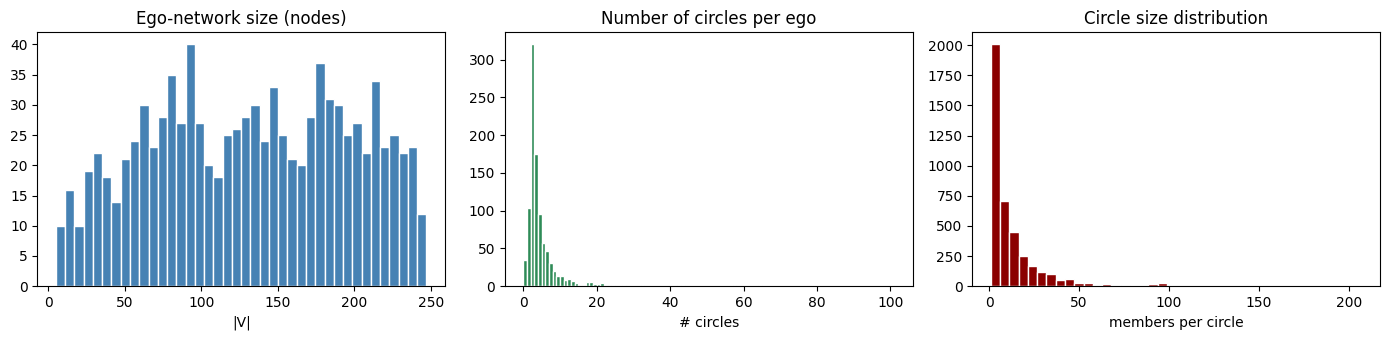

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

axes[0].hist(stats_df["nodes"], bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Ego-network size (nodes)")
axes[0].set_xlabel("|V|")

axes[1].hist(stats_df["n_circles"], bins=range(0, stats_df["n_circles"].max() + 2),
             color="seagreen", edgecolor="white")
axes[1].set_title("Number of circles per ego")
axes[1].set_xlabel("# circles")

all_circle_sizes = [s for sizes in stats_df["circle_sizes"] for s in sizes]
axes[2].hist(all_circle_sizes, bins=40, color="darkred", edgecolor="white")
axes[2].set_title("Circle size distribution")
axes[2].set_xlabel("members per circle")

plt.tight_layout()
plt.savefig("ego_stats.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Save the cleaned graph for next notebooks

We save the GCC in igraph's binary format so the next notebook (community detection) loads it instantly.

In [15]:
out_path = DATA_DIR / "twitter_gcc.pickle"
gcc.write_pickle(str(out_path))
print(f"Saved GCC to {out_path}")
print(f"File size: {out_path.stat().st_size / 1e6:.1f} MB")

Saved GCC to data/twitter_gcc.pickle
File size: 12.1 MB


## 7. Summary & decisions for the next step

Fill these in after running everything above:

| Question | Answer |
|---|---|
| Combined graph size | \_\_\_ nodes / \_\_\_ edges |
| GCC fraction | \_\_\_ % |
| Reciprocity | \_\_\_ |
| Power-law-like? | \_\_\_ |
| Global clustering | \_\_\_ |
| # ego-networks | 973 |
| Avg circles per ego | \_\_\_ |

**Decisions to lock in before notebook 02:**
1. Run main analysis on the **GCC** (drop tiny disconnected components).
2. Use **collapse** mode for directed→undirected (keeps more signal than mutual-only).
3. Plan B will iterate over all 973 ego-networks; for each, run Louvain & Leiden, compare to circles via NMI / ARI / F1.

**Next notebook (`02_community_detection.ipynb`) will:**
- Run Louvain on GCC, record modularity + runtime + #communities + size distribution
- Run Leiden on GCC, same
- Repeat with multiple random seeds (Louvain is non-deterministic)
- Plan B: loop over ego-networks, compute NMI/ARI vs. circles